In [1]:
import os
import dill
import pandas as pd
import seaborn as sns
import numpy as np

# perplexity
from evaluate import load

# softmax
from hfppl.util import softmax

# configure for retina display
%config InlineBackend.figure_format = "retina"

# set the style and context
sns.set_theme(context='talk', style='whitegrid', palette='muted')

In [2]:
with open("hf_auth_token.txt", "r") as f:
    os.environ["HF_TOKEN"] = f.read().strip()

In [3]:
TASK_NAME_DICT = {
    "c01": "word01",
    "c02": "word02",
    "c03": "word03",
    "c04": "sent01",
    "c05": "sent02",
    "c06a": "sent03",
    "c07": "sent04",
    "c08": "para01",
    "c09": "para02",
    "c10": "para03",
    "c11": "para04",
    "c12": "para05",
    "c14": "pass01",
}

MODEL_NAME_DICT = {
    "CollieModelRejectionSampling": "Rejection Sampling",
    "CollieModelSent01": "SMC Steering",
    "CollieModelSent02": "SMC Steering",
    "CollieModelSent03": "SMC Steering",
    "CollieModelSent04": "SMC Steering",
    "CollieModelPara01": "SMC Steering",
    "CollieModelPara02": "SMC Steering",
    "CollieModelPara03": "SMC Steering",
    "CollieModelPara04": "SMC Steering",
    "CollieModelPara05": "SMC Steering",
}

In [4]:
USE_CACHED_RESULTS = True
# USE_CACHED_RESULTS = False

# RESULTS_DIR = "results/2024-08-12-21-46-24"
RESULTS_DIR = "results/2024-09-03-17-07-40"

RESULTS_FILENAME = "results.csv"
# RESULTS_FILENAME_WITH_PERPLEXITY = "results_eval_with_perplexity.csv"
RESULTS_FILENAME_WITH_PERPLEXITY = "results_eval_with_perplexity_base_model.csv"

# PERPLEXITY_MODEL = "meta-llama/Meta-Llama-3-8B-Instruct"
PERPLEXITY_MODEL = "meta-llama/Meta-Llama-3-8B"

In [5]:
df = pd.read_csv(os.path.join(RESULTS_DIR, RESULTS_FILENAME))

In [6]:
df

,task,example_n,example_idx,model,n_particles,particle_id,valid,weight,tokens,text,prompt
0,wiki_c08,0,0,CollieModelPara01,8,0,True,-33.839363,57,"He walked down the street, enjoying the warm ...",<|begin_of_text|><|start_header_id|>system<|en...
1,wiki_c08,0,0,CollieModelPara01,8,1,True,-33.839381,65,He walked into the room with a confident stri...,<|begin_of_text|><|start_header_id|>system<|en...
2,wiki_c08,0,0,CollieModelPara01,8,2,True,-33.839362,48,He went to the store. He bought a new phone. ...,<|begin_of_text|><|start_header_id|>system<|en...
3,wiki_c08,0,0,CollieModelPara01,8,3,True,-33.839373,61,He walked into the room with a sense of deter...,<|begin_of_text|><|start_header_id|>system<|en...
4,wiki_c08,0,0,CollieModelPara01,8,4,True,-33.839357,40,He walked down the street. He was feeling ver...,<|begin_of_text|><|start_header_id|>system<|en...
...,...,...,...,...,...,...,...,...,...,...,...
4659,wiki_c12,88,88,CollieModelRejectionSampling,8,3,True,-0.980829,33,The students eagerly boarded the bus to head b...,<|begin_of_text|><|start_header_id|>system<|en...
4660,wiki_c12,88,88,CollieModelRejectionSampling,8,4,True,-0.980829,38,I attended elementary School. My favorite TV s...,<|begin_of_text|><|start_header_id|>system<|en...
4661,wiki_c12,88,88,CollieModelRejectionSampling,8,5,True,-0.980829,33,The students eagerly boarded the bus to head b...,<|begin_of_text|><|start_header_id|>system<|en...
4662,wiki_c12,88,88,CollieModelRejectionSampling,8,6,True,-0.980829,38,I attended elementary School. My favorite TV s...,<|begin_of_text|><|start_header_id|>system<|en...


In [7]:
df["constrained"] = ~df["model"].isin(
    ["CollieModelRejectionSampling", "CollieModelUnconstrained"]
)

In [8]:
df.groupby(["model", "task"])["example_n"].nunique()

model                         task    
CollieModelPara01             wiki_c08     9
CollieModelPara02             wiki_c09    92
CollieModelPara03             wiki_c10    92
CollieModelPara04             wiki_c11    15
CollieModelPara05             wiki_c12    72
CollieModelRejectionSampling  wiki_c08     9
                              wiki_c09    94
                              wiki_c10    93
                              wiki_c11    18
                              wiki_c12    89
Name: example_n, dtype: int64

In [9]:
with pd.option_context("display.max_colwidth", None):
    display(df[df.constrained & ~df.valid][["task", "example_idx", "model", "text"]])

,task,example_idx,model,text
147,wiki_c09,0,CollieModelPara02,"The sun rises slowly over the horizon, painting the sky with hues of pink and orange. The air is"
149,wiki_c09,0,CollieModelPara02,"The sun rises slowly over the horizon, casting a warm glow over the landscape. Morning dew clings to the grassy blades, refracting the light into tiny rainbows. As the day awakens, the air is"
150,wiki_c09,0,CollieModelPara02,"The sun sets slowly over the horizon, casting a warm orange glow over the landscape. The trees sway gently in the breeze, their leaves rustling softly against each other. The air is"
153,wiki_c09,1,CollieModelPara02,"Clouds gathered in the evening sky, their soft gray masses drifting lazily across the horizon. The air was filled with the sweet scent of blooming flowers, and the sound of birdsong echoed through the stillness. As the sun dipped lower, the colors of the landscape deepened, and the world seemed to"
157,wiki_c09,1,CollieModelPara02,"As sunbeams danced across the morning dew, the air was filled with the sweet scent of blooming flowers. The warm rays illuminated the vibrant colors of the garden, creating a sense of serenity. The gentle breeze rustled the leaves of the trees, producing a soothing melody. The fragrance of fresh cut grass wafted through the air, adding to"
...,...,...,...,...
3947,wiki_c12,88,CollieModelPara05,"The new student transferred to the prestigious university to attend classes at the School. The summer of that year, I spent most of my days working at the local ice cream shop in the hot July of that year in the year of the birth of my first child in the year of the birth of my first child in the year of the birth of my first child in the year of the birth of my first child in the year of the birth of my first child in the year of the birth of my first child in the year of the birth of my first child in the year of the birth of my first child in the year of the birth of my"
3948,wiki_c12,88,CollieModelPara05,"The new student was excited to start at the prestigious university School. The year was significant because it marked the beginning of a new era in space exploration, culminating in the historic Mars landing of July of the year of our lord nineteen hundred and ninety seven and so forth as the seasons went by slowly and steadily unfolding like a blooming flower in full bloom in the spring seasons of life and the world around us was full of hope and promise and the air was filled with the sweet scent of blooming flowers and fresh cut grass and the sound of birds chirping in the morning seasons and the warmth of the sun on the face of the earth and all"
3949,wiki_c12,88,CollieModelPara05,"As I walked into the building, I couldn't help but think about all the memories I made at my old School. It was a sunny day in July of the year that would go down in history as the hottest summer of all time, marked by a devastating drought that lasted until the following year's seasons had passed by in a blur of dry heat and cracked earth that seemed to stretch on forever in the summer of Nineteen Ninety-Seven years ago this year would be a memorable one in many ways and the nostalgia of that year is still felt today even as we look back on the many triumphs and struggles of the time spent at"
3950,wiki_c12,88,CollieModelPara05,"Here is the generated paragraph that meets the constraints you provided below are three sentences with the last word being School,? seasons, and and respectively as requested in the given instructions above till the end of each sentence until the last sentence till the end of the paragraph as requested in the given instructions above till the end of the paragraph as requested in the given instructions above till the end of the paragraph as requested in the given instructions above till the end of the paragraph as requested in the given instructions above till the end of the paragraph as requested in the given instructions above till the end of the paragraph as requested 

# Construct eval DF

In [10]:
def sample_examples(df: pd.DataFrame, seed: int = 0):
    """Takes a weighted sample of the particles for each example."""

    rng = np.random.default_rng(seed)
    df_eval = []

    for (task, example_n, model, n_particles), df_group in df.groupby(
        ["task", "example_n", "model", "n_particles"]
    ):
        df_group_filtered = df_group[df_group["weight"] != -float("inf")]

        if len(df_group_filtered) > 0:
            weights = softmax(df_group_filtered["weight"].tolist())
        else:
            df_group_filtered = df_group
            weights = np.ones(len(df_group_filtered)) / len(df_group_filtered)

        idx = rng.choice(range(len(df_group_filtered)), p=weights)
        row = df_group.iloc[idx]
        df_eval.append(row)

    df_eval = pd.DataFrame(df_eval)
    return df_eval

In [31]:
if USE_CACHED_RESULTS and os.path.exists(
    os.path.join(RESULTS_DIR, RESULTS_FILENAME_WITH_PERPLEXITY)
):
    df_eval = pd.read_csv(os.path.join(RESULTS_DIR, RESULTS_FILENAME_WITH_PERPLEXITY))
    print(f"Loaded cached results from {RESULTS_FILENAME_WITH_PERPLEXITY}")
else:
    df_eval = sample_examples(df)
    df_eval["task_name"] = df_eval["task"].map(
        lambda task_name: task_name.split("_")[0]
        + "_"
        + TASK_NAME_DICT[task_name.split("_")[1]]
    )
    df_eval["model_name"] = df_eval["model"].map(MODEL_NAME_DICT)
    print(f"No cached results found at {RESULTS_FILENAME_WITH_PERPLEXITY}. Constructed new DataFrame.")

df_eval = df_eval.sort_values(["task", "example_n", "model_name", "n_particles"])

Loaded cached results from results_eval_with_perplexity_base_model.csv


In [32]:
df_eval

,task,example_n,example_idx,model,n_particles,particle_id,valid,weight,tokens,text,prompt,constrained,task_name,model_name,perplexity
1,wiki_c08,0,0,CollieModelRejectionSampling,8,2,True,0.000000,59,"He walked down the street, lost in his thought...",<|begin_of_text|><|start_header_id|>system<|en...,False,wiki_para01,Rejection Sampling,5.398235
0,wiki_c08,0,0,CollieModelPara01,8,5,True,-33.839361,40,He walked into the room with confidence. He w...,<|begin_of_text|><|start_header_id|>system<|en...,True,wiki_para01,SMC Steering,12.094825
3,wiki_c08,1,1,CollieModelRejectionSampling,8,0,True,0.000000,52,The sun was shining brightly in the sky. The b...,<|begin_of_text|><|start_header_id|>system<|en...,False,wiki_para01,Rejection Sampling,4.478173
2,wiki_c08,1,1,CollieModelPara01,8,0,True,-38.370545,37,The sun was shining brightly in the clear blu...,<|begin_of_text|><|start_header_id|>system<|en...,True,wiki_para01,SMC Steering,9.213440
5,wiki_c08,2,2,CollieModelRejectionSampling,8,7,True,0.000000,75,"In the small town of Willow Creek, In the morn...",<|begin_of_text|><|start_header_id|>system<|en...,False,wiki_para01,Rejection Sampling,6.740520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577,wiki_c12,86,86,CollieModelPara05,8,3,False,-inf,129,The new student arrived on campus eager to sta...,<|begin_of_text|><|start_header_id|>system<|en...,True,wiki_para05,SMC Steering,8.319141
580,wiki_c12,87,87,CollieModelRejectionSampling,8,5,True,-0.980829,92,"As the election season heated up, the charisma...",<|begin_of_text|><|start_header_id|>system<|en...,False,wiki_para05,Rejection Sampling,11.427190
579,wiki_c12,87,87,CollieModelPara05,8,4,True,-2.114007,117,"As the debate raged on, the seasoned speaker d...",<|begin_of_text|><|start_header_id|>system<|en...,True,wiki_para05,SMC Steering,11.933682
582,wiki_c12,88,88,CollieModelRejectionSampling,8,0,True,-0.980829,39,She attended her first day at elementary Schoo...,<|begin_of_text|><|start_header_id|>system<|en...,False,wiki_para05,Rejection Sampling,22.743092


## Compute perplexity

In [ ]:
!nvidia-smi

In [34]:
if "perplexity" not in df_eval.columns:

    # CUDA_DEVICE = None
    CUDA_DEVICE = "1"
    BATCH_SIZE = 32

    if CUDA_DEVICE is not None:
        os.environ["CUDA_VISIBLE_DEVICES"] = str(CUDA_DEVICE)
        perplexity = load("perplexity", module_type="metric")
        results = perplexity.compute(
            predictions=df_eval["text"].tolist(),
            model_id=PERPLEXITY_MODEL,
            batch_size=BATCH_SIZE,
            add_start_token=True,
        )
        df_eval["perplexity"] = results["perplexities"]
        df_eval.to_csv(os.path.join(RESULTS_DIR, RESULTS_FILENAME_WITH_PERPLEXITY), index=False)
    else:
        print(
            f"Perplexity missing from DataFrame. Please choose a device to run the perplexity computation."
        )

# Tables

In [35]:
df_eval.groupby(["task_name" , "model_name"])["valid"].agg(["mean", "std"])

mean       std
task_name   model_name                            
wiki_para01 Rejection Sampling  1.000000  0.000000
            SMC Steering        1.000000  0.000000
wiki_para02 Rejection Sampling  0.755319  0.432203
            SMC Steering        0.891304  0.312963
wiki_para03 Rejection Sampling  0.752688  0.433788
            SMC Steering        0.967391  0.178583
wiki_para04 Rejection Sampling  0.666667  0.485071
            SMC Steering        0.933333  0.258199
wiki_para05 Rejection Sampling  0.685393  0.466990
            SMC Steering        0.541667  0.501757

# Plots

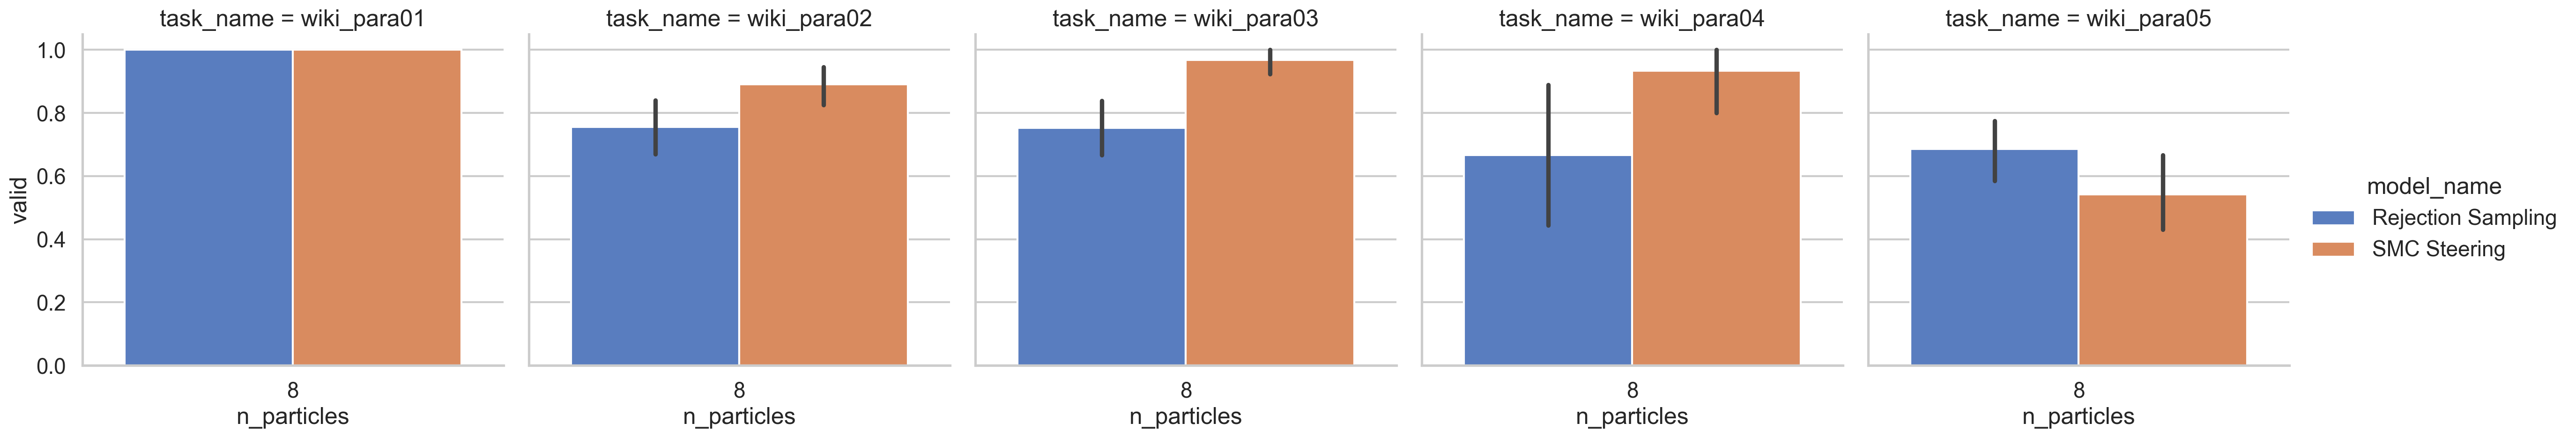

In [36]:
g = sns.catplot(
    data=df_eval,
    # kind="point",
    kind="bar",
    col="task_name",
    x="n_particles",
    y="valid",
    hue="model_name",
)

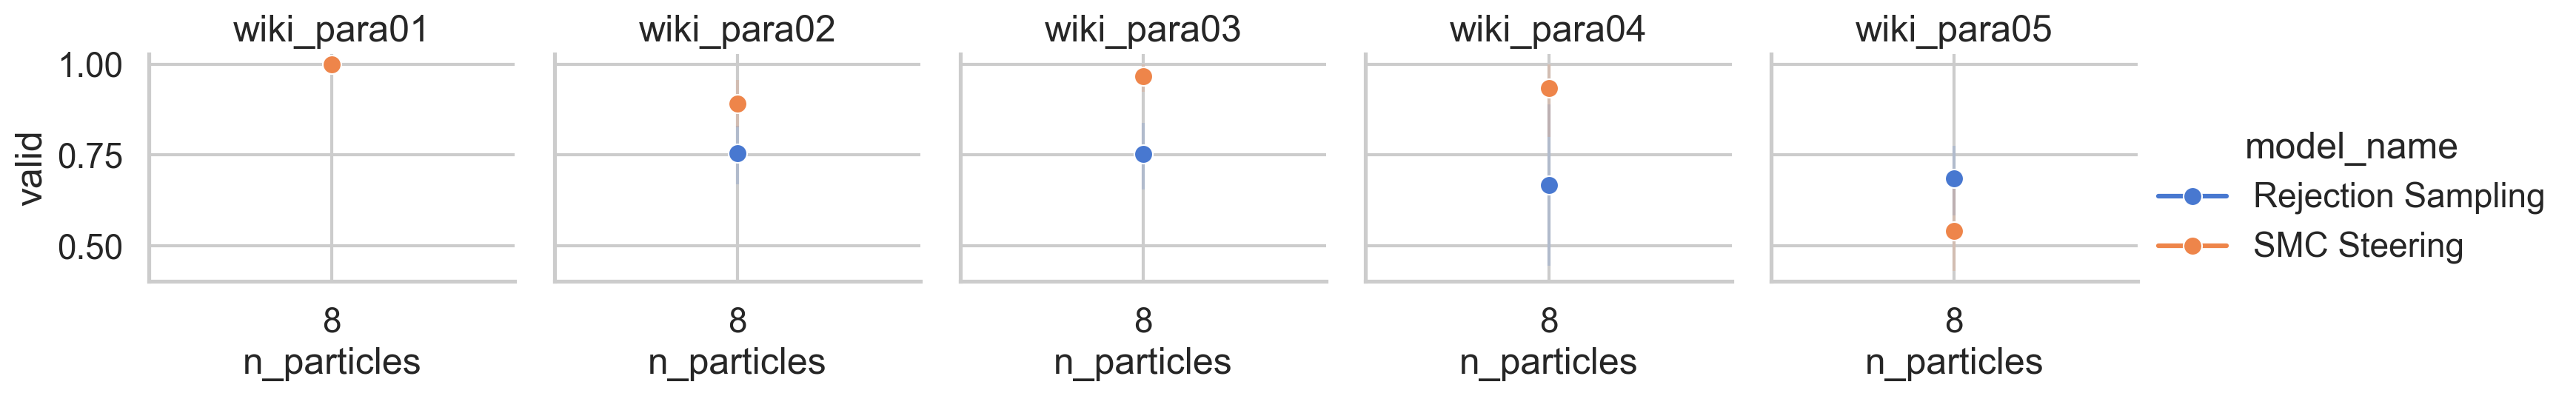

In [37]:
# Using FacetGrid instead of catplot
g = sns.FacetGrid(df_eval, col="task_name", hue="model_name", aspect=1.0)
g.map(sns.lineplot, "n_particles", "valid", marker="o")
g.add_legend()

# Set x-axis labels to correspond exactly to the values of the points
for ax in g.axes.flat:
    x_values = df_eval["n_particles"].unique()
    ax.set_xticks(x_values)
    ax.set_xticklabels(x_values)

    # Remove "task_name = " from the subtitle
    ax.set_title(ax.get_title().replace("task_name = ", ""))

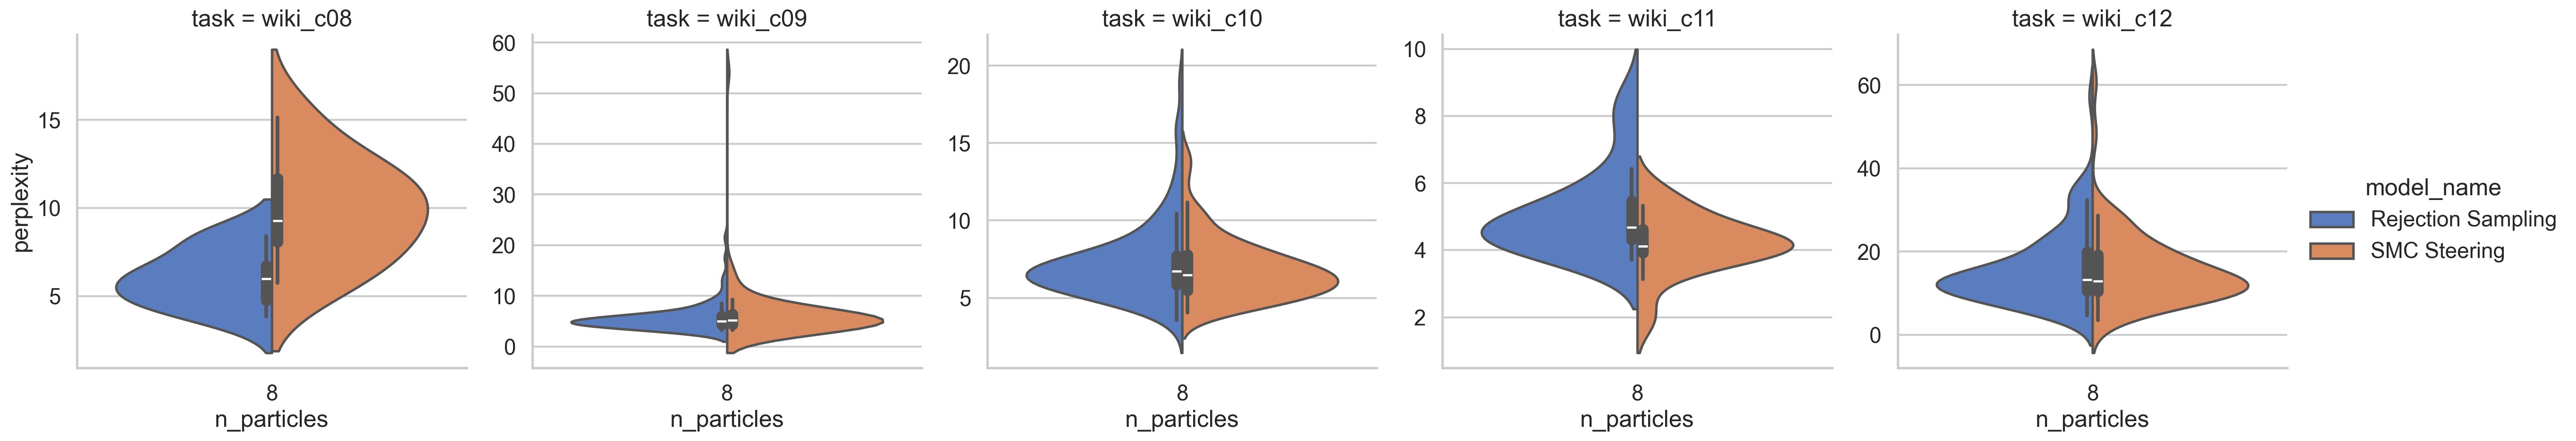

In [38]:
sns.catplot(
    data=df_eval,
    col="task",
    hue="model_name",
    x="n_particles",
    y="perplexity",
    kind="violin",
    split=True,
    sharey=False,
);

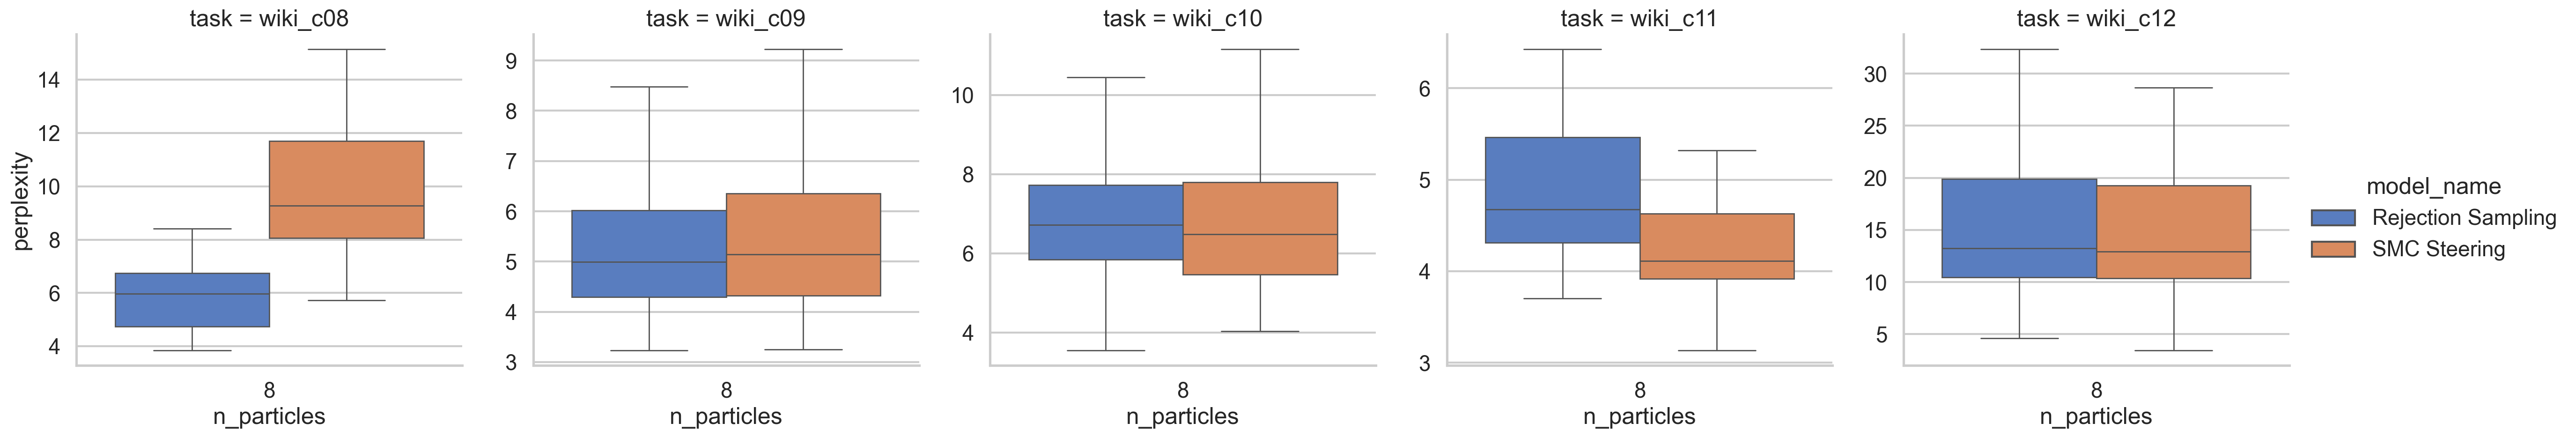

In [39]:
sns.catplot(
    data=df_eval,
    col="task",
    hue="model_name",
    x="n_particles",
    y="perplexity",
    kind="box",
    sharey=False,
    showfliers=False,
);

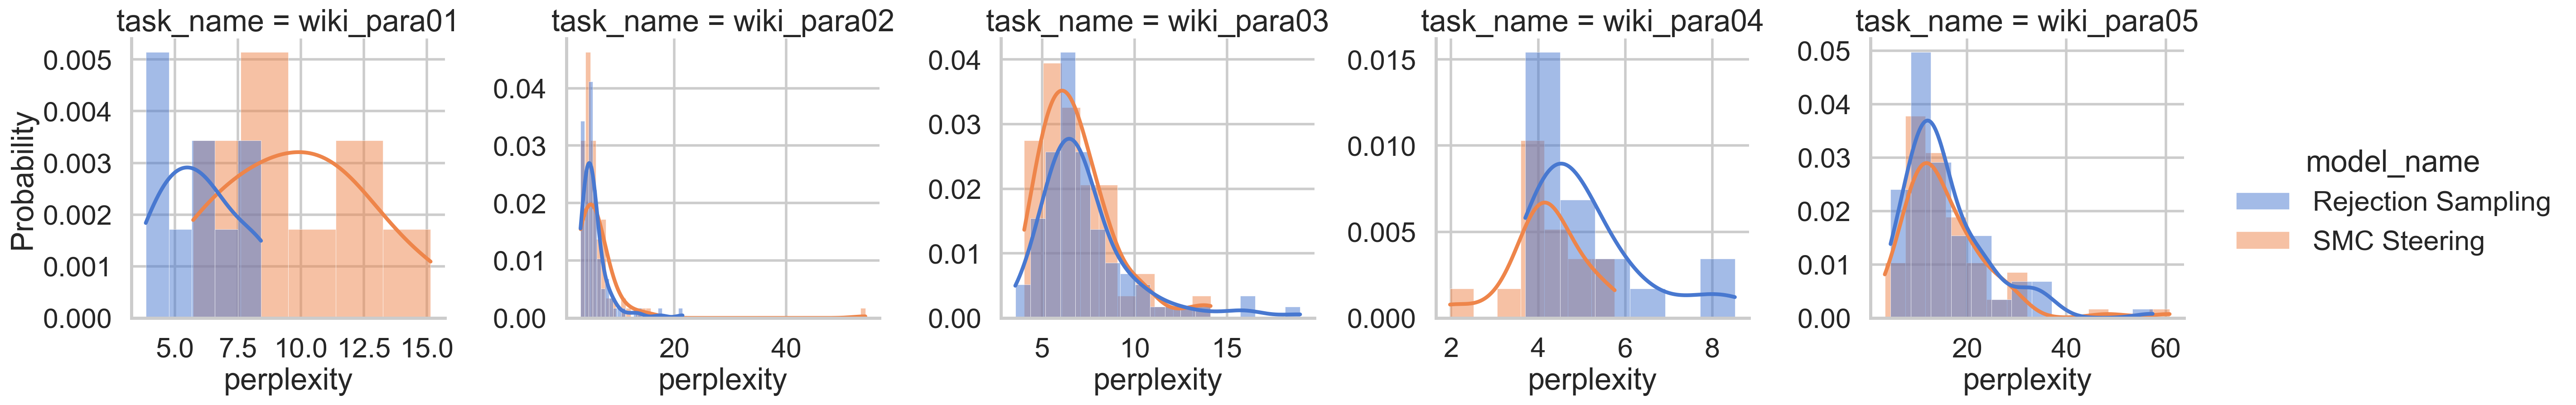

In [40]:
with sns.plotting_context(context="poster"):
    sns.displot(
        data=df_eval,
        col="task_name",
        hue="model_name",
        x="perplexity",
        kind="hist",
        stat="probability",
        kde=True,
        common_bins=False,
        facet_kws=dict(sharex=False, sharey=False),
    )

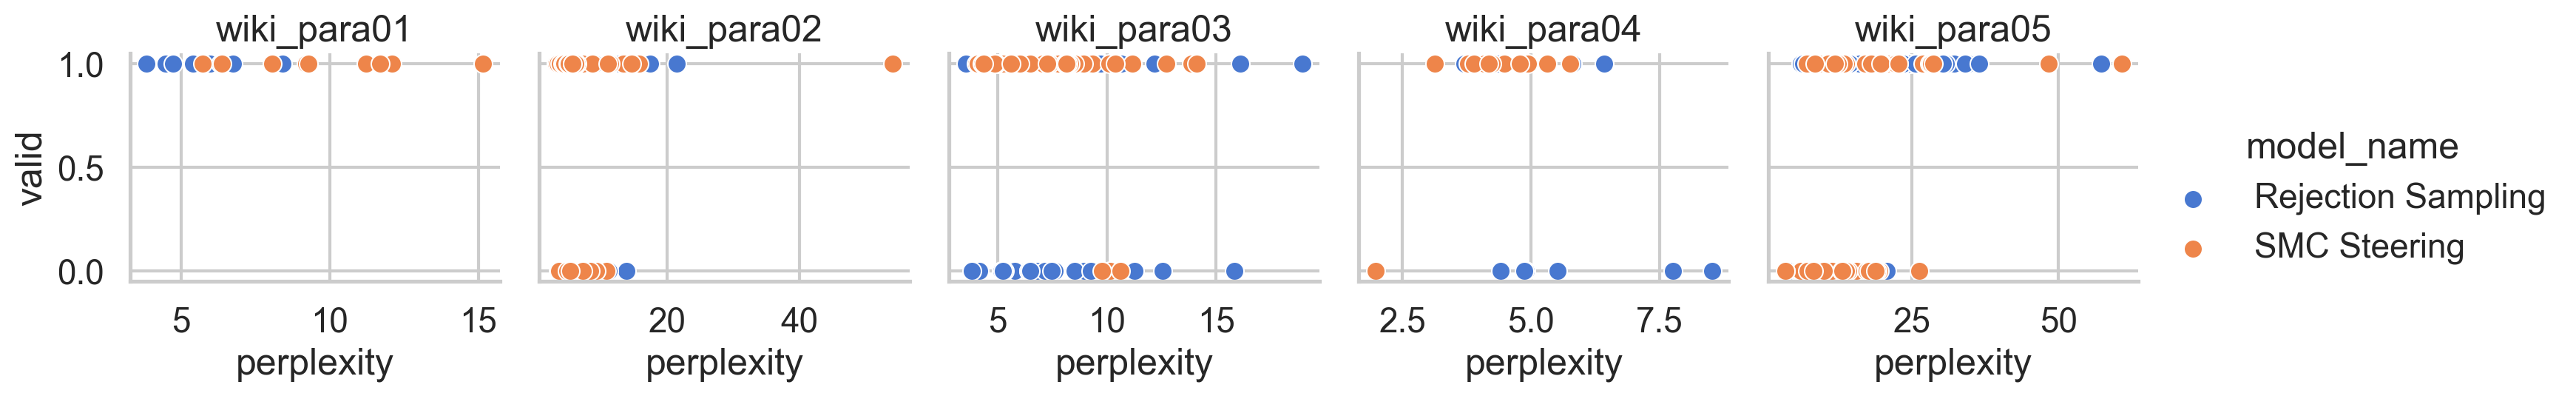

In [41]:
# Using FacetGrid instead of catplot
g = sns.FacetGrid(df_eval, col="task_name", hue="model_name", aspect=1.0, sharex=False)
g.map(sns.scatterplot, "perplexity", "valid", marker="o")
g.add_legend()

# Set x-axis labels to correspond exactly to the values of the points
for ax in g.axes.flat:

    # Remove "task_name = " from the subtitle
    ax.set_title(ax.get_title().replace("task_name = ", ""))

# Error analysis

In [21]:
# Display full text
with pd.option_context("display.max_colwidth", None):
    display(df_eval[(df_eval.model_name == "SMC Steering") & ~df_eval.valid][["task", "example_idx", "text"]])

,task,example_idx,text
34,wiki_c09,8,"Silent moonlight filtered through the window, casting an eerie glow on the room. The shadows danced across the walls, like dark, wispy fingers. In the stillness, the sound of the wind outside seemed to"
36,wiki_c09,9,"The sun rises over the horizon, casting a warm glow over the landscape. The air is"
53,wiki_c09,18,"The sun rises slowly over the horizon, casting a warm glow over the landscape. The birds chirp softly in the trees, their sweet melodies filling the air. A gentle breeze rustles the leaves, causing them to sway gently in the wind. The world awakens, full of possibility and"
103,wiki_c09,43,"The sun was setting over the horizon, casting a warm orange glow over the landscape. The air was filled with the sweet scent of blooming flowers and the soft chirping of crickets. The gentle breeze rustled through the trees, creating a soothing melody that seemed to"
130,wiki_c09,57,"The sun sets slowly over the rolling hills, casting a warm orange glow over the landscape. The air is"
146,wiki_c09,65,"The sun sets slowly over the horizon, casting a warm glow over the landscape. The stars begin to twinkle like diamonds in the night sky. The world is"
168,wiki_c09,76,"The sun sets slowly over the rolling hills, painting the sky with vibrant hues of orange and pink. The air is"
176,wiki_c09,80,"The sun rises slowly over the horizon, casting a warm glow over the landscape. The air is"
182,wiki_c09,83,The sun was setting slowly over the ocean. The sky was painted with hues of orange and pink. The sound of the waves was soothing and calming. The air was filled with the sweet scent of saltwater and seaweed. The stars were beginning to twinkle in
194,wiki_c09,89,"The sun rises slowly over the horizon, casting a warm glow over the landscape. The gentle breeze rustles the leaves of the tall trees, causing the branches to sway softly. The air is"


In [22]:
# Load the dataset

with open("Collie/data/all_data.dill", "rb") as f:
    collie_dataset = dill.load(f)

In [23]:
collie_dataset["wiki_c10"][64]

{'example': ' Ikebukuro is the setting of the Japanese manga and TV drama Ikebukuro West Gate Park.   Ikebukuro is the setting of the Japanese light novel, anime, and manga series Durarara!!.  "Ikebukuro" is the name of a 16-minute-long track from the Brian Eno album, The Shutov Assembly.  Ikebukuro is also represented in the multimedial project by King Records Hypnosis Mic: Division Rap Battle',
 'metadata': {'index': 164398, 'title': 'Ikebukuro'},
 'targets': [4, 14, 18],
 'constraint': <collie.constraints.All at 0x7ff6ebf7c5e0>,
 'prompt': 'Please generate a paragraph:\n1) with exactly 4 sentences;\n2) with all sentences having at least 14 words;\n3) with all sentences having at most 18 words.'}